# INTRODUCTION AND EDA


The data is taken from Kaggle and the path is provided below.

Three different Analytical models are going to be used on this dataset: RFM, Cohort Retention and CLTV Analysis.

In [1]:
import kagglehub

path = kagglehub.dataset_download("mashlyn/online-retail-ii-uci")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'online-retail-ii-uci' dataset.
Path to dataset files: /kaggle/input/online-retail-ii-uci


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px
from matplotlib import gridspec

pd.options.display.float_format = '{:.6f}'.format
# to avoid scientific notation

In [3]:
retail_df = pd.read_csv("/kaggle/input/online-retail-ii-uci/online_retail_II.csv")
retail_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.950000,13085.000000,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.750000,13085.000000,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.750000,13085.000000,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.100000,13085.000000,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.250000,13085.000000,United Kingdom


**InvoiceNo:** Invoice number. Nominal. A 6-digit integral number uniquely assigned to each transaction. If this code starts with the letter 'c', it indicates a cancellation. WILL BE USED.

**StockCode:** Product (item) code. Nominal. A 5-digit integral number uniquely assigned to each distinct product.WILL NOT BE USED.

**Description:** Product (item) name. Nominal. WILL NOT BE USED.

**Quantity:** The quantities of each product (item) per transaction. Numeric. WILL BE USED.

**InvoiceDate:** Invice date and time. Numeric. The day and time when a transaction was generated. WILL BE USED.

**UnitPrice:** Unit price. Numeric. Product price per unit in sterling (Â£). WILL BE USED.

**CustomerID:** Customer number. Nominal. A 5-digit integral number uniquely assigned to each customer. WILL BE USED.

**Country:** Country name. Nominal. The name of the country where a customer resides. WILL NOT BE USED.

In [4]:
retail_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [5]:
retail_df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,4382
Quantity,0
InvoiceDate,0
Price,0
Customer ID,243007
Country,0


There are missing value in two columns. In some cases we would be able to fix them by filling with another data. For example, missing columns about income could be filled with average income of people with similar age, gender and location. However, customer ID is necessary for RFM, thus we drop missing values.

In [6]:
retail_df.dropna(inplace = True)
retail_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.950000,13085.000000,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.750000,13085.000000,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.750000,13085.000000,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.100000,13085.000000,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.250000,13085.000000,United Kingdom


In [7]:
retail_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 824364 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      824364 non-null  object 
 1   StockCode    824364 non-null  object 
 2   Description  824364 non-null  object 
 3   Quantity     824364 non-null  int64  
 4   InvoiceDate  824364 non-null  object 
 5   Price        824364 non-null  float64
 6   Customer ID  824364 non-null  float64
 7   Country      824364 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 56.6+ MB


In [8]:
retail_df.describe()

,Quantity,Price,Customer ID
count,824364.000000,824364.000000,824364.000000
mean,12.414574,3.676800,15324.638504
std,188.976099,70.241388,1697.464450
min,-80995.000000,0.000000,12346.000000
25%,2.000000,1.250000,13975.000000
50%,5.000000,1.950000,15255.000000
75%,12.000000,3.750000,16797.000000
max,80995.000000,38970.000000,18287.000000


Quantity columns has negative values and price has zeros, so they will be removed

In [9]:
retail_df = retail_df[retail_df["Quantity"] > 0]
retail_df = retail_df[retail_df["Price"] > 0]

In [10]:
retail_df.describe()

,Quantity,Price,Customer ID
count,805549.000000,805549.000000,805549.000000
mean,13.290522,3.206561,15331.954970
std,143.634088,29.199173,1696.737039
min,1.000000,0.001000,12346.000000
25%,2.000000,1.250000,13982.000000
50%,5.000000,1.950000,15271.000000
75%,12.000000,3.750000,16805.000000
max,80995.000000,10953.500000,18287.000000


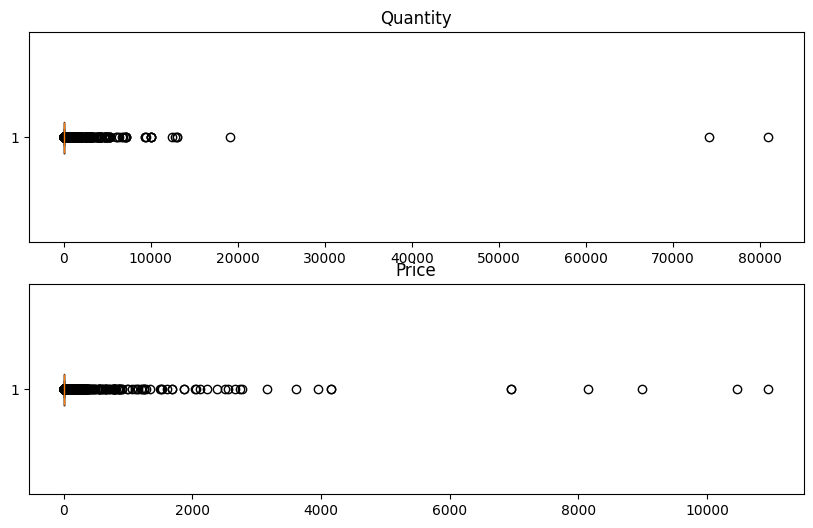

In [11]:
f, ax = plt.subplots(2, 1, figsize=(10, 6))
col_list = ["Quantity", "Price"]

for i in range(0, 2):
    ax[i].boxplot(retail_df[col_list[i]], vert=False)
    ax[i].set_title(col_list[i])
# Boxplot to check for outliers

Both quantity and price cloumns have outliers.
I am not going to removed them, but use clamping.
Because outliers negatively affect the CLTV model.

In [12]:
print(retail_df["Quantity"].quantile(0.01))
print(retail_df["Quantity"].quantile(0.99))
print(retail_df["Price"].quantile(0.01))
print(retail_df["Price"].quantile(0.99))
# calculating percentiles for to be sure

1.0
128.0
0.29
14.95


In [13]:
def outlier_thresholds(dataframe, variable):
    percentile001 = dataframe[variable].quantile(0.01)
    percentile099 = dataframe[variable].quantile(0.99)
    interpercentile_range = percentile099 - percentile001
    up_limit = percentile099 + 1.5 * interpercentile_range
    return up_limit
# function calcualting limits

def replace_with_threshold(dataframe, variable):
    up_limit = outlier_thresholds(dataframe, variable)
    dataframe.loc[(dataframe[variable] > up_limit), variable] = up_limit
# function to clamp the outliers

replace_with_threshold(retail_df, "Quantity")
replace_with_threshold(retail_df, "Price")

/tmp/ipykernel_142378/1306954360.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '318.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dataframe.loc[(dataframe[variable] > up_limit), variable] = up_limit


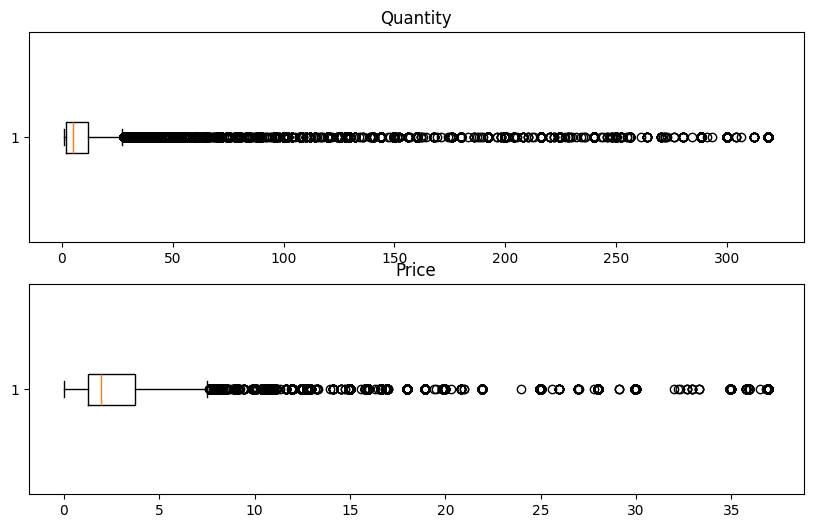

In [14]:
f, ax = plt.subplots(2, 1, figsize=(10, 6))
col_list = ["Quantity", "Price"]

for i in range(0, 2):
    ax[i].boxplot(retail_df[col_list[i]], vert=False)
    ax[i].set_title(col_list[i])
# check if it works

Now we can calculate the total sales column by multiplying price to quantity.

In [15]:
retail_df['TPrice']=retail_df.Quantity*retail_df.Price
retail_df.head()
# added total sales

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12.000000,2009-12-01 07:45:00,6.950000,13085.000000,United Kingdom,83.400000
1,489434,79323P,PINK CHERRY LIGHTS,12.000000,2009-12-01 07:45:00,6.750000,13085.000000,United Kingdom,81.000000
2,489434,79323W,WHITE CHERRY LIGHTS,12.000000,2009-12-01 07:45:00,6.750000,13085.000000,United Kingdom,81.000000
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48.000000,2009-12-01 07:45:00,2.100000,13085.000000,United Kingdom,100.800000
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24.000000,2009-12-01 07:45:00,1.250000,13085.000000,United Kingdom,30.000000


In [16]:
retail_df.describe()

,Quantity,Price,Customer ID,TPrice
count,805549.000000,805549.000000,805549.000000,805549.000000
mean,11.841087,2.950138,15331.954970,20.627925
std,26.828279,3.238483,1696.737039,51.741921
min,1.000000,0.001000,12346.000000,0.001000
25%,2.000000,1.250000,13982.000000,4.950000
50%,5.000000,1.950000,15271.000000,11.850000
75%,12.000000,3.750000,16805.000000,19.500000
max,318.500000,36.940000,18287.000000,3884.000000


In [17]:
retail_df.describe(include='O')

,Invoice,StockCode,Description,InvoiceDate,Country
count,805549,805549,805549,805549,805549
unique,36969,4631,5283,34585,41
top,576339,85123A,WHITE HANGING HEART T-LIGHT HOLDER,2011-11-14 15:27:00,United Kingdom
freq,542,5188,5181,542,725250


In [18]:
retail_df["InvoiceDate"] = pd.to_datetime(retail_df['InvoiceDate'])

In [19]:
retail_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 805549 entries, 0 to 1067370
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      805549 non-null  object        
 1   StockCode    805549 non-null  object        
 2   Description  805549 non-null  object        
 3   Quantity     805549 non-null  float64       
 4   InvoiceDate  805549 non-null  datetime64[ns]
 5   Price        805549 non-null  float64       
 6   Customer ID  805549 non-null  float64       
 7   Country      805549 non-null  object        
 8   TPrice       805549 non-null  float64       
dtypes: datetime64[ns](1), float64(4), object(4)
memory usage: 61.5+ MB


# RFM ANALYSIS




Mostly used for marketing analysis. This model allows us to divide the customers into several groups and the marketing department could work with these groups by approaching various activities, such as bringing back the customers from group "Cannot lose them" with certification or personal discounts for group "Promissing"

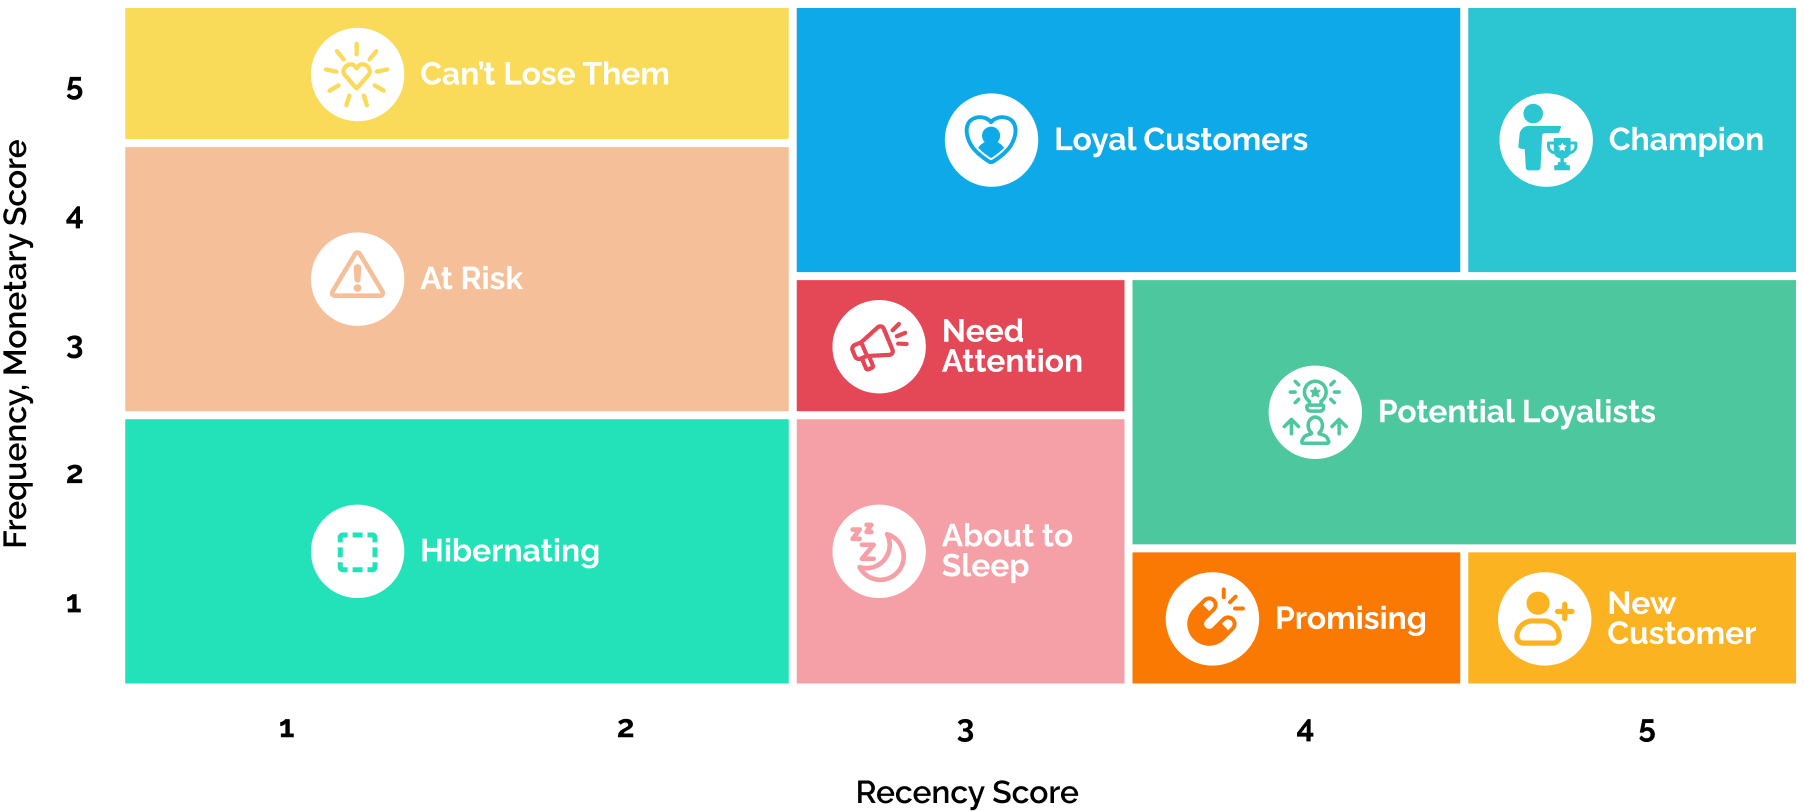

In [20]:
last_day= retail_df.InvoiceDate.max() + pd.Timedelta(days=1)
last_day
# it is for recency calculation

Timestamp('2011-12-10 12:50:00')

In [21]:
rfm_df= retail_df.groupby("Customer ID").agg(
      Recency=("InvoiceDate", lambda x: (last_day - x.max()).days),
      Frequency=("Invoice", "nunique"),
      Monetary=("TPrice", "sum"))
rfm_df.head()


,Recency,Frequency,Monetary
Customer ID,,,
12346.000000,326,12,704.100000
12347.000000,2,8,5633.320000
12348.000000,75,5,1991.860000
12349.000000,19,4,3786.500000
12350.000000,310,1,331.340000


As it was shown in the previous photo; recency, frequency and monetary will be changed to 1 to 5 scale from worst to best.
For frequency and monetary bigger means better and vice versa for recency. In this case we will cut by percentile, but in job we rely on business acumen

In [22]:
rfm_df["Recency"] = pd.qcut(rfm_df["Recency"], 5, labels = [5, 4, 3, 2, 1], duplicates='drop')
rfm_df["Frequency"] = pd.qcut(rfm_df["Frequency"].rank(method = "first"), 5, labels = [1, 2, 3, 4, 5], duplicates='drop')
rfm_df["Monetary"] = pd.qcut(rfm_df["Monetary"], 5, labels = [1, 2, 3, 4, 5], duplicates='drop')
# duplicates are droped, because some recency could be met very often

In [23]:
rfm_df.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.000000,2,5,3
12347.000000,5,4,5
12348.000000,3,4,4
12349.000000,5,3,5
12350.000000,2,1,2


In [24]:
rfm_df['RFM_Score'] = (rfm_df['Recency'].astype(str) +
                       rfm_df['Frequency'].astype(str) +
                       rfm_df['Monetary'].astype(str)).astype(int)
rfm_df.head()

,Recency,Frequency,Monetary,RFM_Score
Customer ID,,,,
12346.000000,2,5,3,253
12347.000000,5,4,5,545
12348.000000,3,4,4,344
12349.000000,5,3,5,535
12350.000000,2,1,2,212


In [25]:
Champion = [555, 554, 544, 545, 454, 455, 445]
Loyal_Customer = [543, 444, 435, 355, 354, 345, 344, 335]
Potential_Loyalist = [553, 551, 552, 541, 542, 533, 532, 531, 452, 451, 442, 441, 431, 453, 433, 432, 423, 353, 352, 351, 342, 341, 333, 323]
New_Customer = [512, 511, 422, 421, 412, 411, 311]
Promising = [525, 524, 523, 522, 521, 515, 514, 513, 425,424, 413,414,415, 315, 314, 313]
Need_Attention = [535, 534, 443, 434, 343, 334, 325, 324]
Cannot_Lose_Them = [155, 154, 144, 214,215,115, 114, 113]
About_to_Sleep = [331, 321, 312, 221, 213]
At_Risk = [255, 254, 245, 244, 253, 252, 243, 242, 235, 234, 225, 224, 153, 152, 145, 143, 142, 135, 134, 133, 125, 124]
Hibernating = [332, 322, 231, 241, 251, 233, 232, 223, 222, 132, 123, 122, 212, 211]
Lost = [111, 112, 121, 131, 141, 151]

# the borders of the groups could be discussed within the business team
# and sometimes people avoid using 'lost' and include this group into Hibernating
# but this doesnot matter for the project

In [26]:
def segmentation(score):
  lists=list()
  for number in score:
    if number in Champion:
        segm= "Champion"
    elif number in Loyal_Customer:
        segm= "Loyal_Customer"
    elif number in Potential_Loyalist:
        segm= "Potential_Loyalist"
    elif number in New_Customer:
        segm= "New_Customer"
    elif number in Promising:
        segm= "Promising"
    elif number in Need_Attention:
        segm= "Need_Attention"
    elif number in Cannot_Lose_Them:
        segm= "Cannot_Lose_Them"
    elif number in About_to_Sleep:
        segm= "About_to_Sleep"
    elif number in At_Risk:
        segm= "At_Risk"
    elif number in Hibernating:
        segm= "Hibernating"
    elif number in Lost:
        segm= "Lost"
    else:
        segm= "Unknown"

    lists.append(segm)
  return lists
rfm_df['Segment']=segmentation(rfm_df['RFM_Score'])
rfm_df.head()
# defining the final segent of customer

,Recency,Frequency,Monetary,RFM_Score,Segment
Customer ID,,,,,
12346.000000,2,5,3,253,At_Risk
12347.000000,5,4,5,545,Champion
12348.000000,3,4,4,344,Loyal_Customer
12349.000000,5,3,5,535,Need_Attention
12350.000000,2,1,2,212,Hibernating


In [27]:
graf = rfm_df['Segment'].value_counts()

fig = px.bar(
     x = graf.index,
     y = graf.values,
     color = graf.index,
     text = graf.values,
     title = "RFM Analysis"
)
fig.update_layout(
    xaxis_title="Segment",
    yaxis_title="Count",
    font=dict(size=15),
    title_font=dict(size=20)
)
fig.show()

Customer base is split between most loyals (Champion and Loyal_customer) and those who have completely disengaged (Lost ad Hivernating). It is common for old marketplaces with strong competitors.

The amount of potential lotalists, promising and new customers shows that there is still opportunity in the market. In order to stay wealthy the company should pay attention to them.
Cannot lose them is the smalles group with says that customers with high sales are hardly loyal and barely leave the company.

But there is a huge amount of customers at risk and need attention, thus the company should think how to increase their loyality.

# COHORT ANALYSIS

Basically, cohort is a group of people who started used product or service at the same period. Usally we use month or fortnight in FMCG retail. I am going to provide retention analysis on this data to discover how many customers stay in the product once they start using it.

The good amount of customers 'stay' defined by the service. For social media and media apps we need use dayli based retention and it should be more them 50%.

For services selling expensive products product that last long yearly retention could be 5% and still considered as perfect.

For FMCG we use fornight period, because people need to buy them often and we need 30-40% retention.

In [28]:
max_date=retail_df.groupby('Customer ID').agg(First_date=("InvoiceDate", "min"))
max_date.head()

,First_date
Customer ID,
12346.000000,2009-12-14 08:34:00
12347.000000,2010-10-31 14:20:00
12348.000000,2010-09-27 14:59:00
12349.000000,2010-04-29 13:20:00
12350.000000,2011-02-02 16:01:00


In [29]:
cohort_df=retail_df[['Customer ID','InvoiceDate']]
cohort_df=cohort_df.merge(max_date, on='Customer ID')
cohort_df=cohort_df.drop_duplicates()
cohort_df['Invoice_month']=(cohort_df['InvoiceDate'] + pd.offsets.MonthBegin(-1)).dt.normalize()
cohort_df['First_month']=(cohort_df['First_date'] + pd.offsets.MonthBegin(-1)).dt.normalize()
cohort_df['Month_diff']=(cohort_df['Invoice_month']-cohort_df['First_month']).dt.days
cohort_df['Month_diff']=(cohort_df['Month_diff']/30).astype(int)
# here I have created several new columns for pivot calculation
cohort_df_quarter=cohort_df.copy()

I am going to do both monthly and quarterly retentions so, i made a copy. I have added the first sale date to calculate the activity of the customers on different periods from this day.

In [30]:
cohort_df=cohort_df[(cohort_df['Month_diff']<13)]

I ussually use only M12 retention for long term check, so I dropped everything bigger.

In [31]:
cohort_df_pivot=cohort_df.pivot_table(index='First_month', columns='Month_diff', values='Customer ID', aggfunc='nunique')

In [32]:
list = [1,2,3,4,5,6,7,8,9,10,11,12]

for i in list:
  cohort_df_pivot[i]=cohort_df_pivot[i]/cohort_df_pivot[0]
# changing alternative numbers to percent

/tmp/ipykernel_142378/1670078780.py:31: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



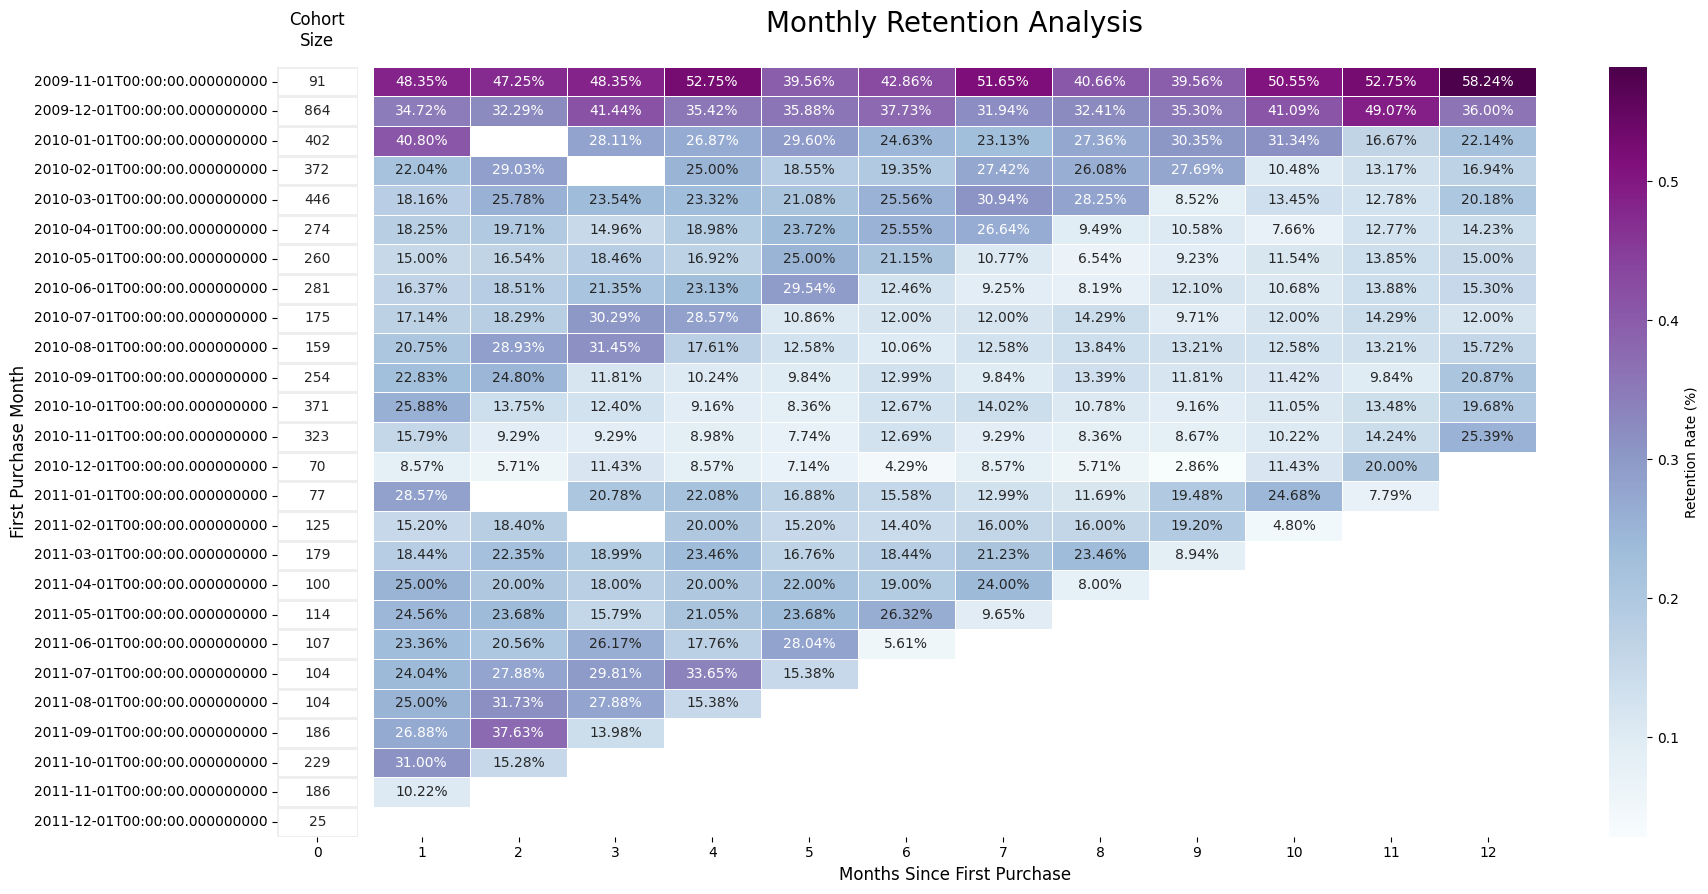

In [33]:
fig = plt.figure(figsize=(20, 10))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 18], wspace=0.02)

ax0 = plt.subplot(gs[0])
sns.heatmap(cohort_df_pivot[[0]],
            annot=True,
            fmt='.0f',
            cbar=False,
            cmap=['white'],
            linewidths=1,
            linecolor='#eeeeee',
            ax=ax0)
ax0.set_title('Cohort\nSize', fontsize=12, pad=15)
ax0.set_ylabel('First Purchase Month', fontsize=12)
ax0.set_xlabel('')

ax1 = plt.subplot(gs[1])
sns.heatmap(cohort_df_pivot.iloc[:, 1:],
            annot=True,
            fmt='.2%',
            cmap='BuPu',
            linewidths=0.5,
            cbar_kws={'label': 'Retention Rate (%)'},
            ax=ax1)

ax1.set_title('Monthly Retention Analysis', fontsize=20, pad=25)
ax1.set_xlabel('Months Since First Purchase', fontsize=12)
ax1.set_ylabel('')
ax1.set_yticks([])

plt.tight_layout()
plt.show()

It is hard to understad the meaning of absolute numbers in the m1,m2,m3,m4 coulns, so it will look better in percents.
But M0 should be in absolute numbers so we can see how much people we have attracted in each month an check if there is an issue.

In [34]:
cohort_df_quarter['First_quarter']=cohort_df_quarter['First_month'].dt.to_period('Q')
cohort_df_quarter['InvoiceDate']=cohort_df_quarter['Invoice_month'].dt.to_period('Q')
cohort_df_quarter['Quarter_diff']=(cohort_df_quarter['Month_diff']/3).astype(int)

In [35]:
cohort_df_quarter_pivot=cohort_df_quarter.pivot_table(index='First_quarter', columns='Quarter_diff', values='Customer ID', aggfunc='nunique')
list = [1,2,3,4,5,6,7,8]
for i in list:
  cohort_df_quarter_pivot[i]=cohort_df_quarter_pivot[i]/cohort_df_quarter_pivot[0]
# changing alternative numbers to percent again

/tmp/ipykernel_142378/3213097565.py:31: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



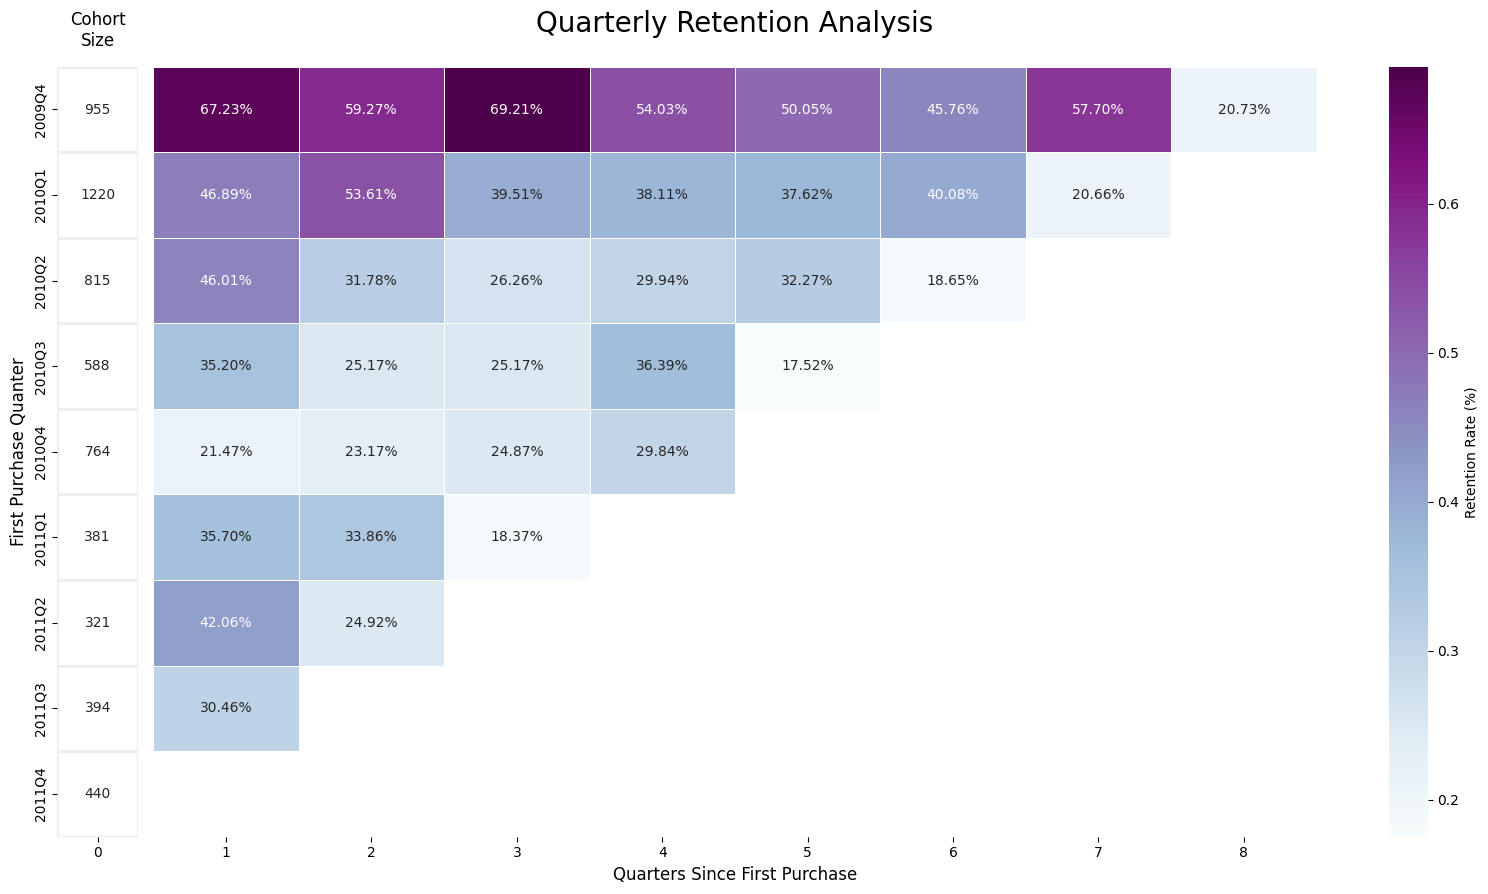

In [36]:
fig = plt.figure(figsize=(20, 10))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 18], wspace=0.02)

ax0 = plt.subplot(gs[0])
sns.heatmap(cohort_df_quarter_pivot[[0]],
            annot=True,
            fmt='.0f',
            cbar=False,
            cmap=['white'],
            linewidths=1,
            linecolor='#eeeeee',
            ax=ax0)
ax0.set_title('Cohort\nSize', fontsize=12, pad=15)
ax0.set_ylabel('First Purchase Quanter', fontsize=12)
ax0.set_xlabel('')

ax1 = plt.subplot(gs[1])
sns.heatmap(cohort_df_quarter_pivot.iloc[:, 1:],
            annot=True,
            fmt='.2%',
            cmap='BuPu',
            linewidths=0.5,
            cbar_kws={'label': 'Retention Rate (%)'},
            ax=ax1)

ax1.set_title('Quarterly Retention Analysis', fontsize=20, pad=25)
ax1.set_xlabel('Quarters Since First Purchase', fontsize=12)
ax1.set_ylabel('')
ax1.set_yticks([])

plt.tight_layout()
plt.show()


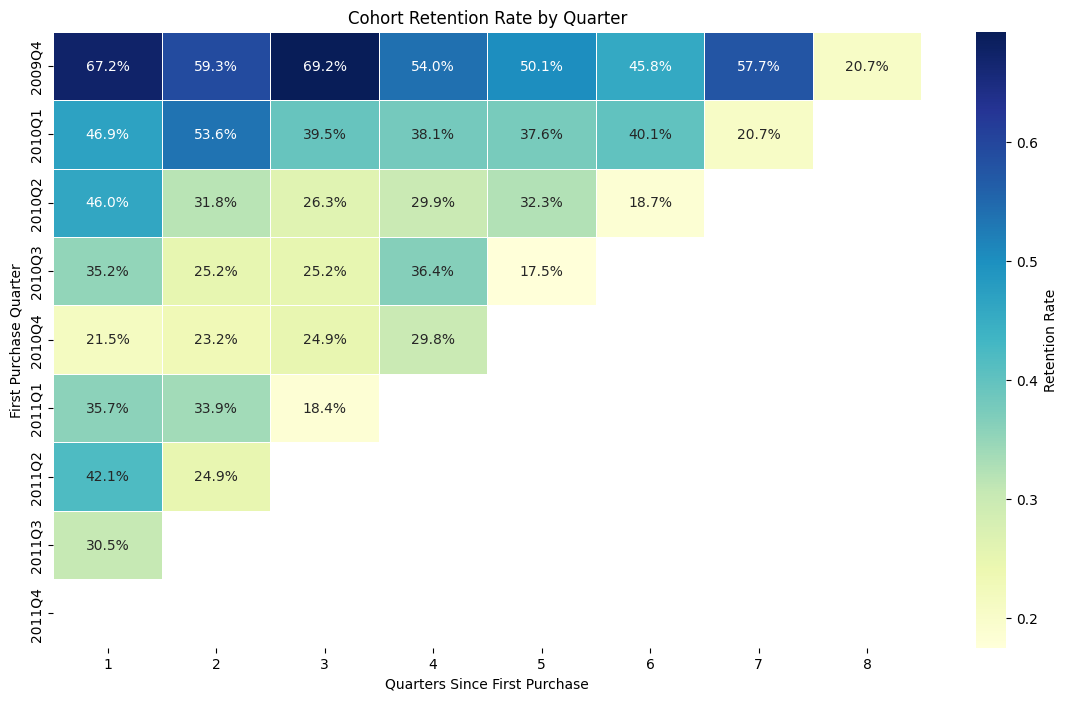

In [37]:

plt.figure(figsize=(14, 8))
plt.title('Cohort Retention Rate by Quarter')

sns.heatmap(cohort_df_quarter_pivot.iloc[:, 1:],
            annot=True,
            fmt='.1%',
            cmap='YlGnBu',
            linewidths=.5,
            cbar_kws={'label': 'Retention Rate'})

plt.ylabel('First Purchase Quarter')
plt.xlabel('Quarters Since First Purchase')
plt.show()

For some products or C-Level reports it is better to use quarterly approach, because it is more readable.

# CLTV ANALYSIS

The models gives us a "price" of customers for given period. So we will be able to calculate unit economics and make decisions like "how much should we invest in customer" or did "we recoup our marketing costs?"
Mostly it is used in paid with RFM to invest in "Cannot lose them" or "Promising" groups.

In [38]:
retail_df['InvoiceDate'].max()

Timestamp('2011-12-09 12:50:00')

In [39]:
retail_df_cltv = retail_df.groupby(['Customer ID', 'InvoiceDate'])['TPrice'].sum().reset_index()
retail_df_cltv['InvoiceDate']=retail_df_cltv['InvoiceDate'].dt.date
retail_df_cltv.head()
#defining necesary data for modeling, but we will shift to rfm data

,Customer ID,InvoiceDate,TPrice
0,12346.000000,2009-12-14,45.000000
1,12346.000000,2009-12-14,22.500000
2,12346.000000,2009-12-14,22.500000
3,12346.000000,2009-12-18,22.500000
4,12346.000000,2009-12-18,1.000000


In [40]:
from lifetimes.utils import calibration_and_holdout_data
from lifetimes import BetaGeoFitter
from sklearn.metrics import mean_squared_error

retail_df_cltv = retail_df.groupby(['Customer ID', 'InvoiceDate'])['TPrice'].sum().reset_index()
retail_df_cltv

cltv_df_train = calibration_and_holdout_data(
    retail_df_cltv,
    customer_id_col='Customer ID',
    datetime_col='InvoiceDate',
    calibration_period_end='2011-09-09',
    observation_period_end='2011-12-09')
# dividing data into train and test in unusual way.

penalizers = [0.0, 0.001, 0.0015, 0.002, 0.0025, 0.003, 0.0035, 0.004, 0.0045, 0.005, 0.0075, 0.01, 0.05, 0.1]
best_penalizer = 0
min_rmse = float('inf')

# list of penalizers to tune

for p in penalizers:
    bgf = BetaGeoFitter(penalizer_coef=p)
    bgf.fit(cltv_df_train['frequency_cal'], cltv_df_train['recency_cal'], cltv_df_train['T_cal'])

    predicted = bgf.predict(cltv_df_train['duration_holdout'],
                            cltv_df_train['frequency_cal'],
                            cltv_df_train['recency_cal'],
                            cltv_df_train['T_cal'])

    if predicted.isnull().any() or np.isinf(predicted).any():
        print(f"Skipping penalizer {p} due to NaN/Inf predictions")
        continue

    rmse = np.sqrt(mean_squared_error(cltv_df_train['frequency_holdout'], predicted))

    if rmse < min_rmse:
        min_rmse = rmse
        best_penalizer = p

print(f"Best Penalizer: {best_penalizer} with RMSE: {min_rmse}")

# process of searching for best parametr

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning:

invalid value encountered in log

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning:

invalid value encountered in log



Skipping penalizer 0.0045 due to NaN/Inf predictions
Skipping penalizer 0.005 due to NaN/Inf predictions


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning:

invalid value encountered in log

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning:

invalid value encountered in log



Skipping penalizer 0.0075 due to NaN/Inf predictions
Skipping penalizer 0.01 due to NaN/Inf predictions
Skipping penalizer 0.05 due to NaN/Inf predictions
Skipping penalizer 0.1 due to NaN/Inf predictions
Best Penalizer: 0.004 with RMSE: 1.2013765892361494


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning:

invalid value encountered in log

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning:

invalid value encountered in log



I have just wanted to little bit tune the BG/NBD model. So we have divide the date into train and test. But the division was unusual, because we have cut the last three month and the model had to predict the numbers from this test using previous data.

In [41]:
cltv_df= retail_df.groupby("Customer ID").agg(
      Recency=("InvoiceDate", lambda x: (last_day - x.max()).days),
      Age=("InvoiceDate", lambda x: (last_day - x.min()).days),
      Frequency=("Invoice", "nunique"),
      Monetary=("TPrice", "sum"))
cltv_df['Frequency']=cltv_df['Frequency']-1
cltv_df=cltv_df[cltv_df['Frequency']>0]
cltv_df
# preparing data for predictions

,Recency,Age,Frequency,Monetary
Customer ID,,,,
12346.000000,326,726,11,704.100000
12347.000000,2,404,7,5633.320000
12348.000000,75,438,4,1991.860000
12349.000000,19,589,3,3786.500000
12352.000000,36,393,9,2098.940000
...,...,...,...,...
18281.000000,181,578,1,201.140000
18282.000000,8,126,1,178.050000
18283.000000,4,658,21,2736.650000


In [42]:
cltv_df[['Frequency', 'Monetary']].corr()
# for BG/NBD these columns should not be correlated
# for business it means that the arpu has high varience

,Frequency,Monetary
Frequency,1.000000,0.651677
Monetary,0.651677,1.000000


In [43]:
from lifetimes import BetaGeoFitter, GammaGammaFitter

bgf = BetaGeoFitter(penalizer_coef=best_penalizer)
bgf.fit(cltv_df['Frequency'], cltv_df['Recency'], cltv_df['Age'])

cltv_df['Future_Orders'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    90, cltv_df['Frequency'], cltv_df['Recency'], cltv_df['Age']
)

# predicting future purchases

In [44]:
ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(cltv_df['Frequency'], cltv_df['Monetary'])


cltv_df['cltv_3_months'] = ggf.customer_lifetime_value(
    bgf,
    cltv_df['Frequency'],
    cltv_df['Recency'],
    cltv_df['Age'],
    cltv_df['Monetary'],
    time=3,
    discount_rate=0.01
)

# predicting future cltv

In [45]:
cltv_df["cltv_segment"] = pd.qcut(cltv_df["cltv_3_months"], 5, labels=["E","D", "C", "B", "A"],duplicates='drop')
cltv_df
# dividing into cltv segments/


,Recency,Age,Frequency,Monetary,Future_Orders,cltv_3_months,cltv_segment
Customer ID,,,,,,,
12346.000000,326,726,11,704.100000,0.002295,1.621437,C
12347.000000,2,404,7,5633.320000,0.000000,0.000000,E
12348.000000,75,438,4,1991.860000,0.003155,6.568313,C
12349.000000,19,589,3,3786.500000,0.000042,0.170332,D
12352.000000,36,393,9,2098.940000,0.000000,0.000013,D
...,...,...,...,...,...,...,...
18281.000000,181,578,1,201.140000,0.086531,22.971229,C
18282.000000,8,126,1,178.050000,0.086411,20.354264,C
18283.000000,4,658,21,2736.650000,0.000000,0.000000,E


In [46]:
cltv_df.cltv_segment.value_counts()

,count
cltv_segment,
E,851
D,851
C,851
B,851
A,851


In [47]:
cltv_to_merge=cltv_df.reset_index()[['Customer ID', 'cltv_3_months']]
rfm_to_merge=rfm_df.reset_index()[['Customer ID', 'Segment']]
segment_price=pd.merge(cltv_to_merge,rfm_to_merge,on='Customer ID')
segment_price=pd.pivot_table(segment_price, index='Segment', values='cltv_3_months', aggfunc='mean')
segment_price.sort_values(by='cltv_3_months',ascending=False)

,cltv_3_months
Segment,
Cannot_Lose_Them,1419.292006
Promising,477.451232
Need_Attention,422.383824
At_Risk,337.684587
New_Customer,215.403246
Potential_Loyalist,175.224513
Hibernating,132.313888
Champion,113.187343
About_to_Sleep,55.658488


So at the end, we see that the group 'Cannot_Lose_Them' should be invested more then others. They spend a lot money and not start leaving, thus coupons and personal discounts should be provided.

WHile the biggest groups Champion, About_to_Sleep, Lost, Loyal_Customer do not need any attention.